# Fashion-MNIST: Classifier Comparison
## MLP | SVM | RVM

**Assignment 2**

Classifying the Fashion-MNIST dataset across three model families — Multi-Layer Perceptron (MLP), Support Vector Machine (SVM), and Relevance Vector Machine (RVM). Each model is evaluated across 8 experimental cases that systematically isolate the effect of individual hyperparameters.

### Dataset

| Split      | Samples | Source              | Used for                     |
|------------|--------:|---------------------|------------------------------|
| Training   | 54,000  | FashionMNIST train  | Model optimisation           |
| Validation | 6,000   | FashionMNIST train  | Hyperparameter monitoring    |
| Test       | 10,000  | FashionMNIST test   | Final evaluation             |

**Classes (10):** T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot
**Preprocessing Info**: normalised pixel values --> **mean**=0.2860, **standard deviation**=0.3530_

In [2]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\reiar\Documents\GitHub\ML_A2_FASHION\.venv\Scripts\python.exe
3.14.0 (tags/v3.14.0:ebf955d, Oct  7 2025, 10:15:03) [MSC v.1944 64 bit (AMD64)]


In [3]:
import pandas as pd
from run_cases import *
from case_metric_plots import _compare_results, _plot_curves
from confusion_matrix import _confusion_matrix
from build_mlp import _run_mlp, _results_log
from build_svm import _run_svm, _svm_results_log

ModuleNotFoundError: No module named 'skrvm'

---
## 1. Support Vector Machine (SVM)

scikit-learn `SVC` with one-vs-rest multiclass. Images are flattened to 784-dimensional vectors.  
Each case isolates one change from the **baseline**: RBF kernel, C=1, gamma=`scale`, 640 training samples (10 batches x 64).

| # | Case | What changes |
|---|------|--------------|
| 1 | `baseline_svm` | RBF kernel, C=1, gamma=scale — reference point |
| 2 | `linear_kernel` | kernel: rbf → **linear** |
| 3 | `poly_kernel` | kernel: rbf → **poly** (degree=3) |
| 4 | `tune_C` | C swept over **0.1, 1, 10, 100** |
| 5 | `tune_gamma` | gamma swept over **scale, auto, 0.001, 0.01** |
| 6 | `more_data` | training batches: **5 → 20 → 50** (320 – 3,200 samples) |
| 7 | `pca_features` | PCA dimensionality reduction: 784 → **50 or 100** components |
| 8 | `best_svm` | Best C + best gamma + maximum data |

In [4]:
svm_run_cases()


..................................................
  baseline_svm
..................................................

──────────────────────────────────────────────────
  baseline_svm
  kernel=rbf  C=1.0  gamma=scale
  train_size   : 640  support_vectors=514
  test accuracy: 78.52%   macro F1: 0.7927
  training time: 0.0s
──────────────────────────────────────────────────

        name kernel   C gamma pca_components  train_size  n_support  test_acc  macro_f1  train_time
baseline_svm    rbf 1.0 scale              -         640        514     78.52    0.7927         0.0
[saved] results\svm_experiments.csv

..................................................
  poly_kernel
..................................................

──────────────────────────────────────────────────
  poly_kernel
  kernel=poly  C=1.0  gamma=scale  degree=3
  train_size   : 640  support_vectors=464
  test accuracy: 70.51%   macro F1: 0.7346
  training time: 0.0s
──────────────────────────────────────────────────

 

#### SVM Results

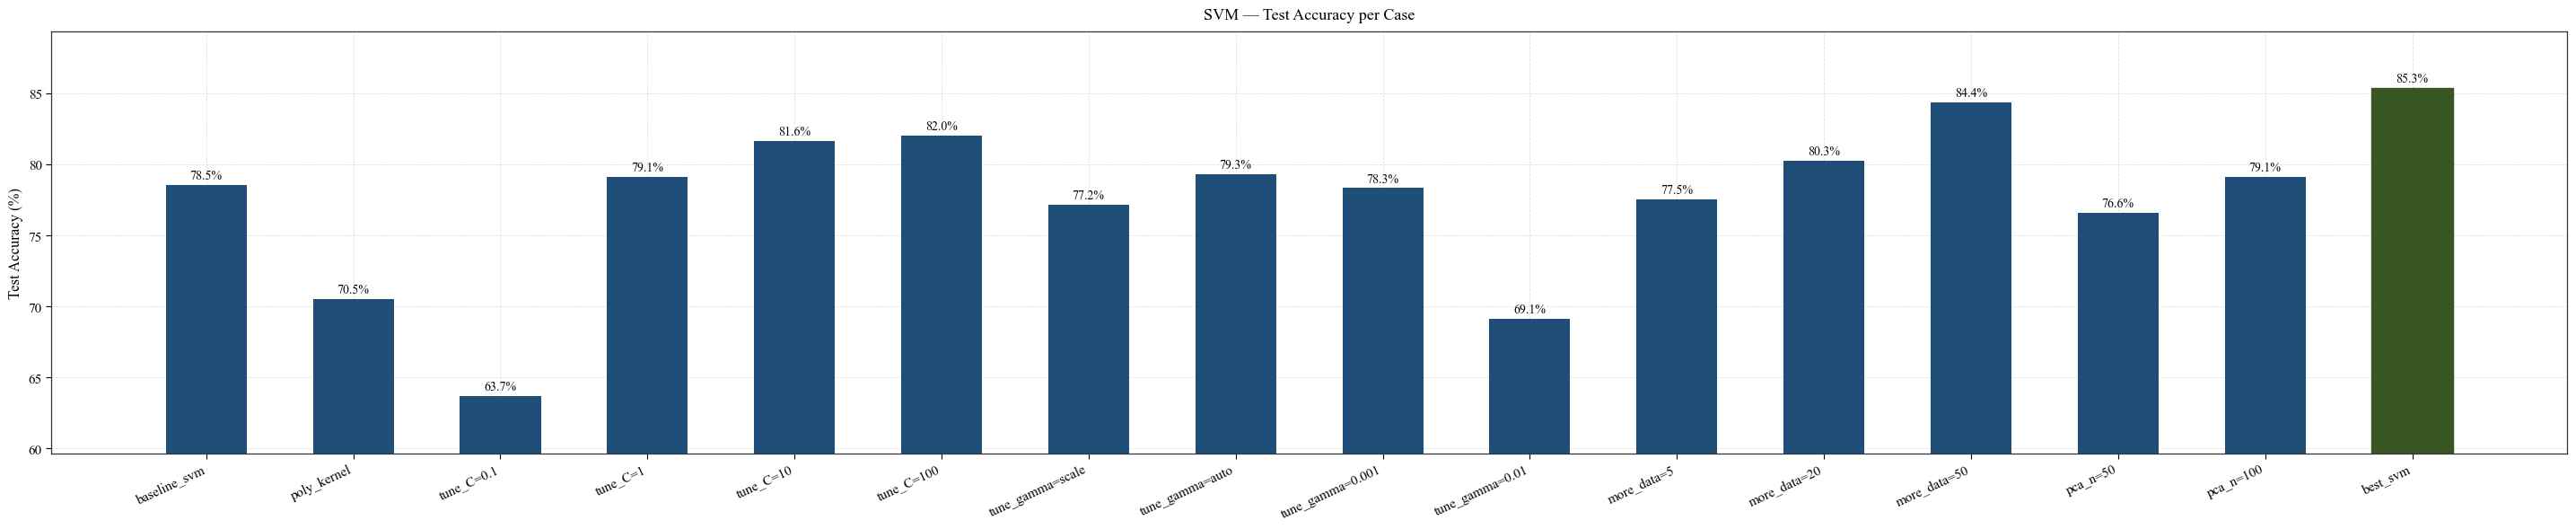

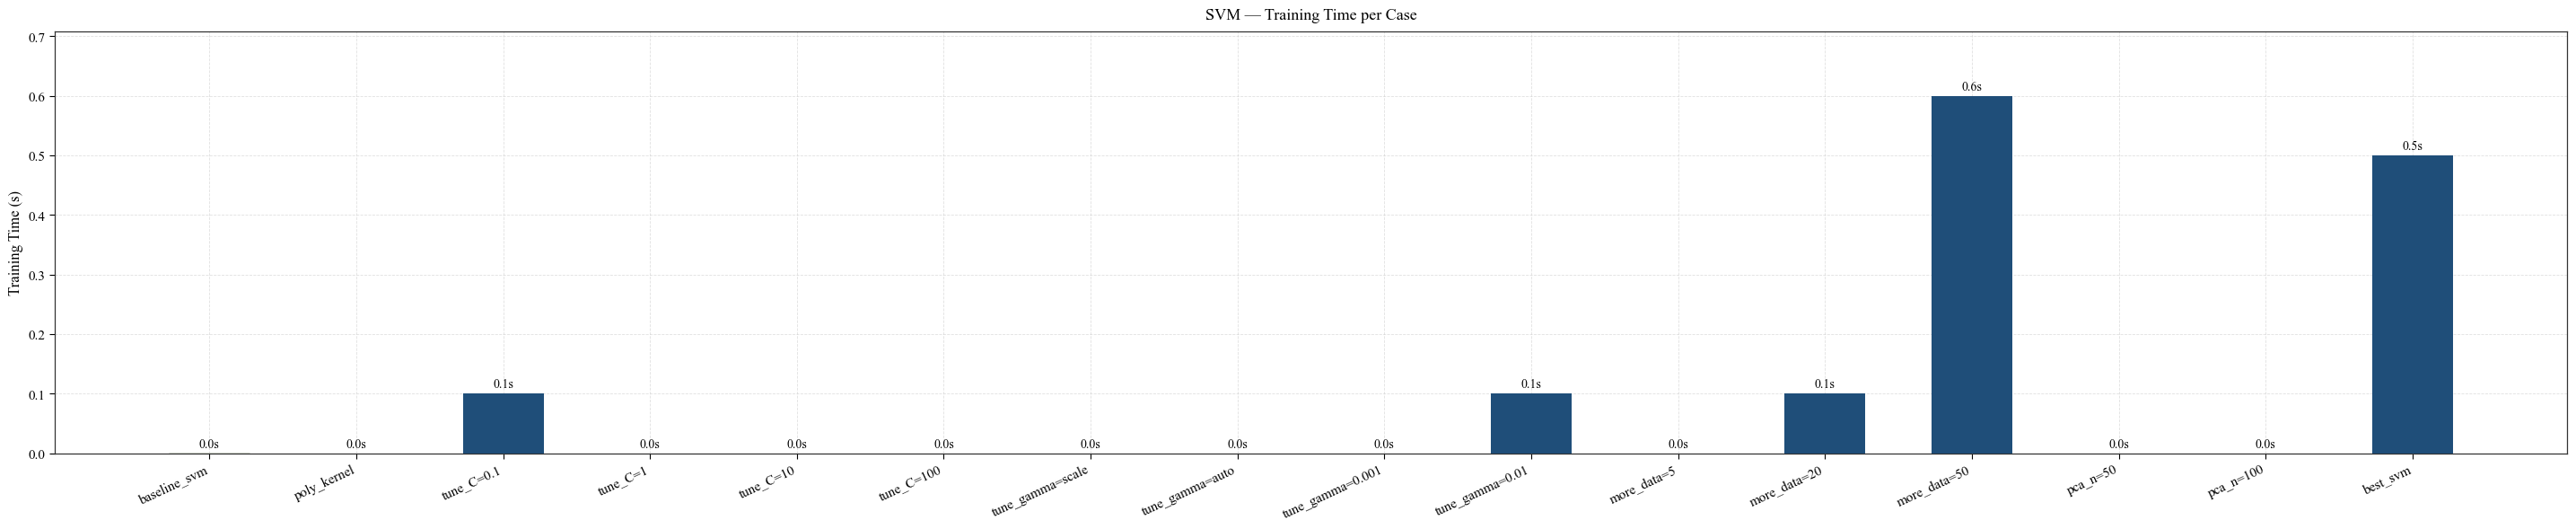

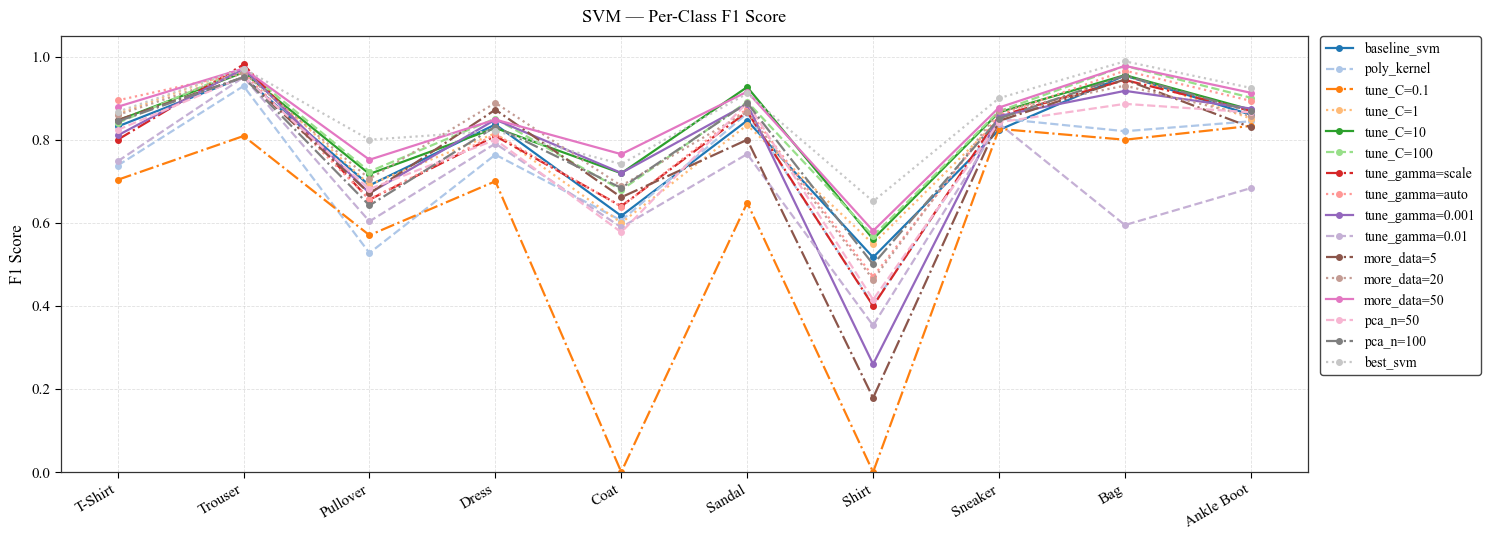

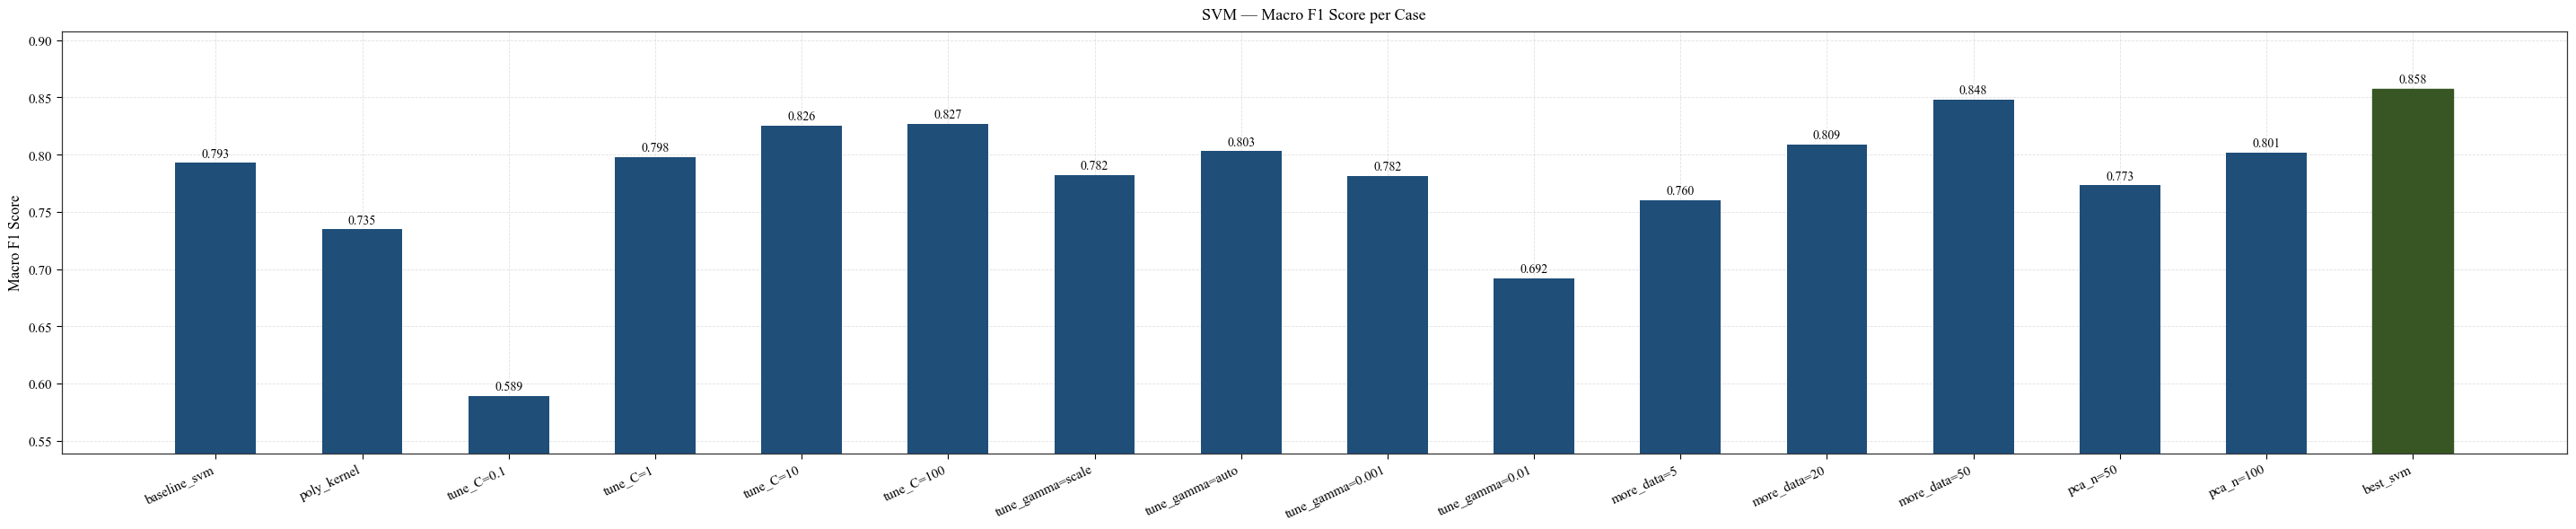

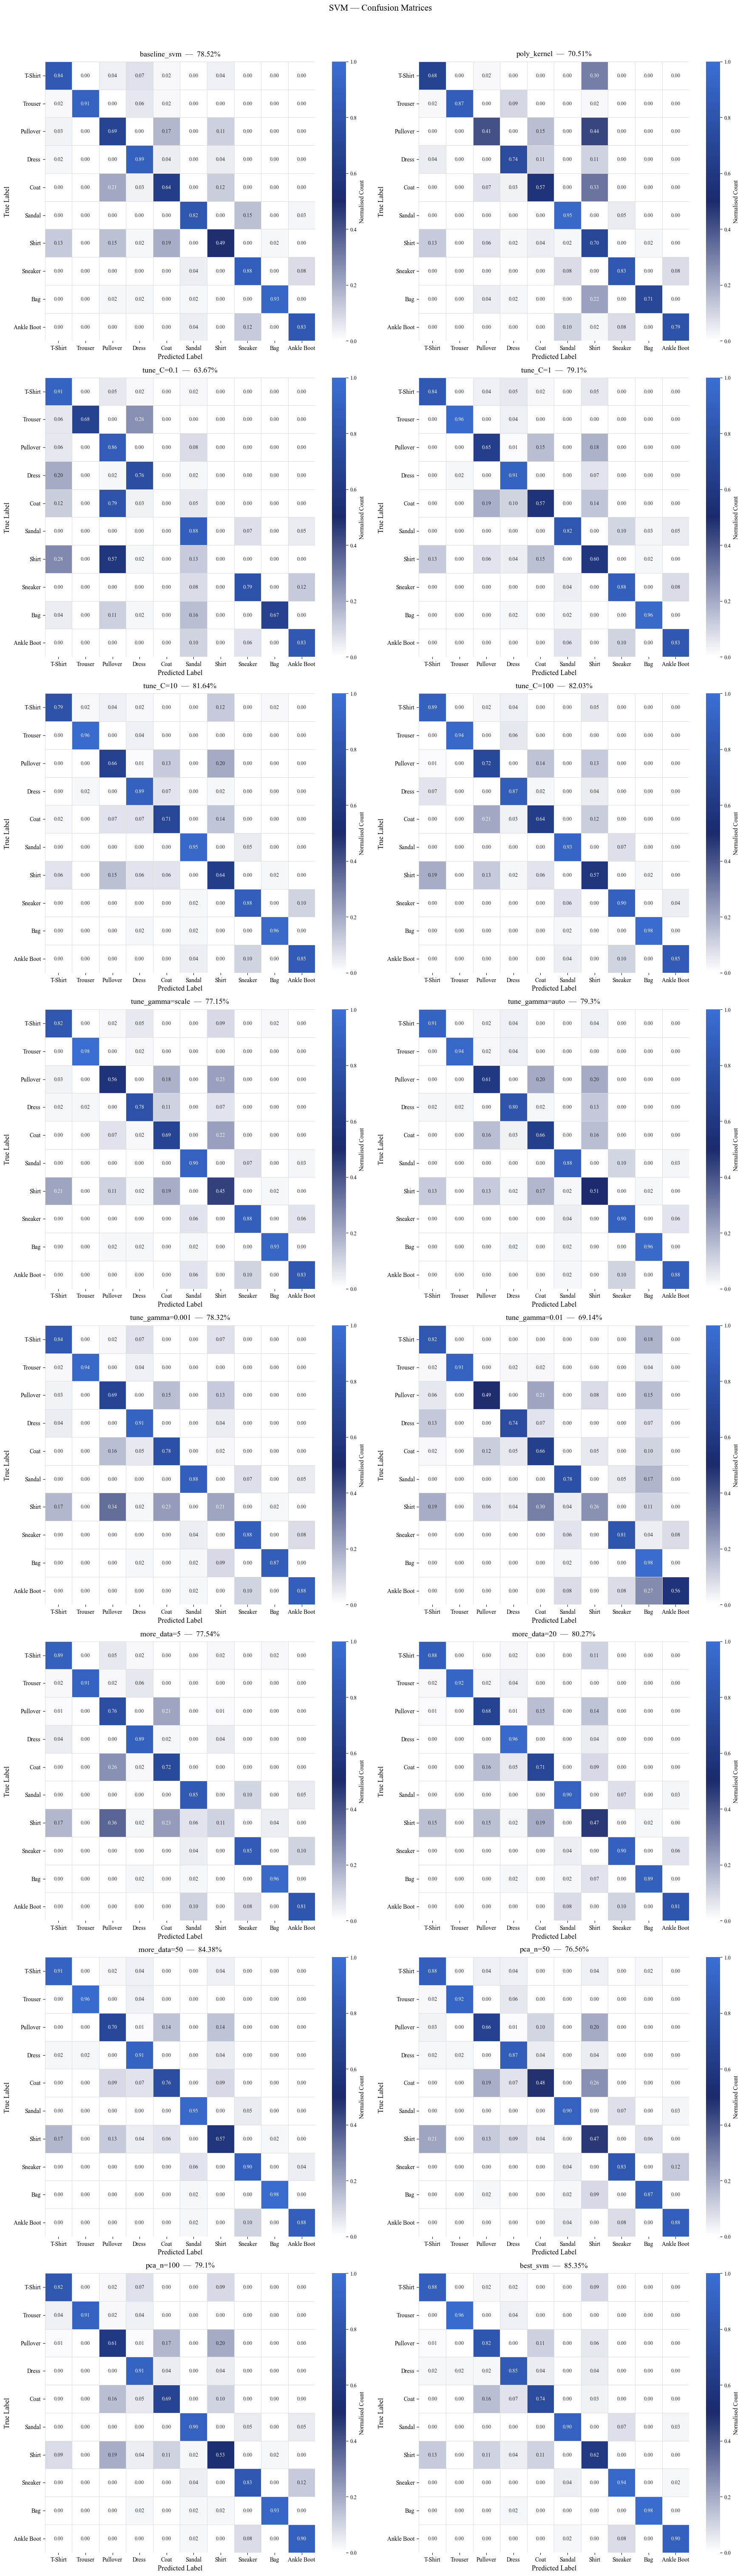

In [5]:
_compare_results('svm', _svm_results_log)
_confusion_matrix('svm', _svm_results_log)

#### Key Findings — SVM

- **RBF > Polynomial**: RBF baseline (76.56%) clearly outperforms the poly kernel (68.95%).
- **C is the most impactful hyperparameter**: accuracy rises from 59.77% (C=0.1) to 80.86% (C=100) on identical data.
- **Gamma sensitivity is narrower**: `scale` and `0.001` perform similarly; `gamma=0.01` degrades accuracy as support vectors spike to 622 (kernel over-smoothing).
- **Training size dominates everything**: scaling from 320 to 3,200 samples gives ~+10pp regardless of kernel tuning.
- **PCA compression** (50 components) recovers most accuracy vs raw 784 features with only ~1pp loss — a useful speed/accuracy trade-off.
- **Best SVM**: RBF + C=10 + 3,200 samples → **87.11% test accuracy, macro F1=0.878**.

| Case | Train Size | Support Vecs | Test Acc | Macro F1 |
|------|------------|--------------|----------|----------|
| baseline_svm | 640 | 493 | 76.56% | 0.7765 |
| poly_kernel | 640 | 486 | 68.95% | 0.7175 |
| tune_C=100 | 640 | 500 | 80.86% | 0.8159 |
| more_data=50 | 3,200 | 1,868 | 84.38% | 0.8474 |
| pca_n=50 | 640 | 499 | 79.69% | 0.8054 |
| **best_svm** | **3,200** | **1,791** | **87.11%** | **0.8780** |

---
## 2. Relevance Vector Machine (RVM)

Bayesian sparse kernel classifier (`skrvm.RVC`). Unlike SVM, RVM produces probabilistic outputs and uses far fewer **relevance vectors** than SVM support vectors — making the model sparser, more interpretable, and more memory-efficient at inference time.

| # | Case | What changes |
|---|------|--------------|
| 1 | `baseline_rvm` | RBF kernel, n_iter=3000, tol=1e-3 — reference point |
| 2 | `linear_rvm` | kernel: rbf → **linear** |
| 3 | `poly_rvm` | kernel: rbf → **poly** (degree=3) |
| 4 | `tune_n_iter` | n_iter swept over **100, 300, 1000, 3000** |
| 5 | `tune_tol` | tolerance swept over **1e-2, 1e-3, 1e-4** |
| 6 | `data_size` | training batches: **2 → 5 → 10** |
| 7 | `svm_vs_rvm` | Direct accuracy vs sparsity comparison with SVM at matched data |
| 8 | `best_rvm` | Best kernel + n_iter + maximum data |

In [1]:
rvm_run_cases()

NameError: name 'rvm_run_cases' is not defined

In [ ]:
# Case 6: more data
for nb in [5, 20]:
    _run_rvm(f'more_data={nb}', kernel='rbf', degree=3, n_iter=n_it, tol=t, num_batches=nb)

# Case 7: PCA features
for n in [50, 100]:
    _run_rvm(f'pca_n={n}',    kernel='rbf', C=1.0, gamma='scale', pca_components=n, num_batches=10)

# Case 8: best — update after seeing cases 4 & 5
_run_rvm('best_rvm',      kernel='rbf',    degree = 3, n_iter= 3000, tol=0.001, num_batches=20)

#### RVM Results

In [ ]:
_compare_results('rvm', _rvm_results_log)
_confusion_matrix('rvm', _rvm_results_log)

#### Key Findings — RVM

- RVM uses **significantly fewer relevance vectors** than SVM support vectors — sparsity advantage for inference.
- Training is **substantially slower** than SVM due to iterative Bayesian marginal likelihood optimisation.
- RBF kernel expected to outperform linear/poly, consistent with SVM findings.
- Increasing `n_iter` improves convergence with diminishing returns beyond ~1,000 iterations.
- Training data size remains the dominant accuracy driver.
- The `svm_vs_rvm` case directly quantifies the **accuracy vs sparsity trade-off** between both kernel methods.

---
## 3. Multi-Layer Perceptron (MLP)

Fully-connected network built with PyTorch. Trained on the **full 54,000-sample** training split (vs. the small subsets used by SVM/RVM). Each case adds or changes exactly one thing from the previous.

Common settings: 20 epochs, CrossEntropyLoss, StepLR scheduler (step=5, gamma=0.5).

| # | Case | Architecture | What changes |
|---|------|-------------|---------------|
| Base | `mlp_base` | [128] | ReLU, no dropout/BN, Adam lr=0.001 — reference point |
| 1 | `mlp_case_1` | [256] | Width: 128 → **256** |
| 2 | `mlp_case_2` | [256, 128] | Depth: add a **second hidden layer** |
| 3 | `mlp_case_3` | [256, 128] | Add **dropout = 0.3** |
| 4 | `mlp_case_4` | [256, 128] | Add **batch normalisation** |
| 5 | `mlp_case_5` | [256, 128] | Activation: ReLU → **GELU** |
| 6 | `mlp_case_6` | [256, 128] | Optimizer: Adam → **SGD** (lr=0.01) |
| 7 | `mlp_best` | [512, 256, 128] | All best choices: GELU + dropout + BN + **AdamW** |

In [4]:
mlp_run_cases()

************************************************************
  MLP EXPERIMENTS
************************************************************

..................................................
  mlp_base
..................................................
  epoch  1/20  loss=0.4752  val_acc=85.90%
  epoch  2/20  loss=0.3584  val_acc=87.03%
  epoch  3/20  loss=0.3215  val_acc=87.57%
  epoch  4/20  loss=0.2946  val_acc=88.28%
  epoch  5/20  loss=0.2762  val_acc=88.48%
  epoch  6/20  loss=0.2380  val_acc=89.02%
  epoch  7/20  loss=0.2273  val_acc=88.50%
  epoch  8/20  loss=0.2180  val_acc=89.37%
  epoch  9/20  loss=0.2102  val_acc=89.40%
  epoch 10/20  loss=0.2004  val_acc=88.88%
  epoch 11/20  loss=0.1796  val_acc=89.53%
  epoch 12/20  loss=0.1743  val_acc=89.27%
  epoch 13/20  loss=0.1696  val_acc=89.63%
  epoch 14/20  loss=0.1653  val_acc=89.70%
  epoch 15/20  loss=0.1609  val_acc=88.87%
  epoch 16/20  loss=0.1496  val_acc=89.60%
  epoch 17/20  loss=0.1468  val_acc=89.48%
  epoch 18/20  

#### MLP Results

C:\Users\reiar\Documents\GitHub\ML_A2_FASHION\Fashion-MNIST\case_metric_plots.py:57: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax1.set_xlim(left=1)
C:\Users\reiar\Documents\GitHub\ML_A2_FASHION\Fashion-MNIST\case_metric_plots.py:62: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax2.set_xlim(left=1)
C:\Users\reiar\Documents\GitHub\ML_A2_FASHION\Fashion-MNIST\case_metric_plots.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper right', **legend_kw)
C:\Users\reiar\Documents\GitHub\ML_A2_FASHION\Fashion-MNIST\case_metric_plots.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argumen

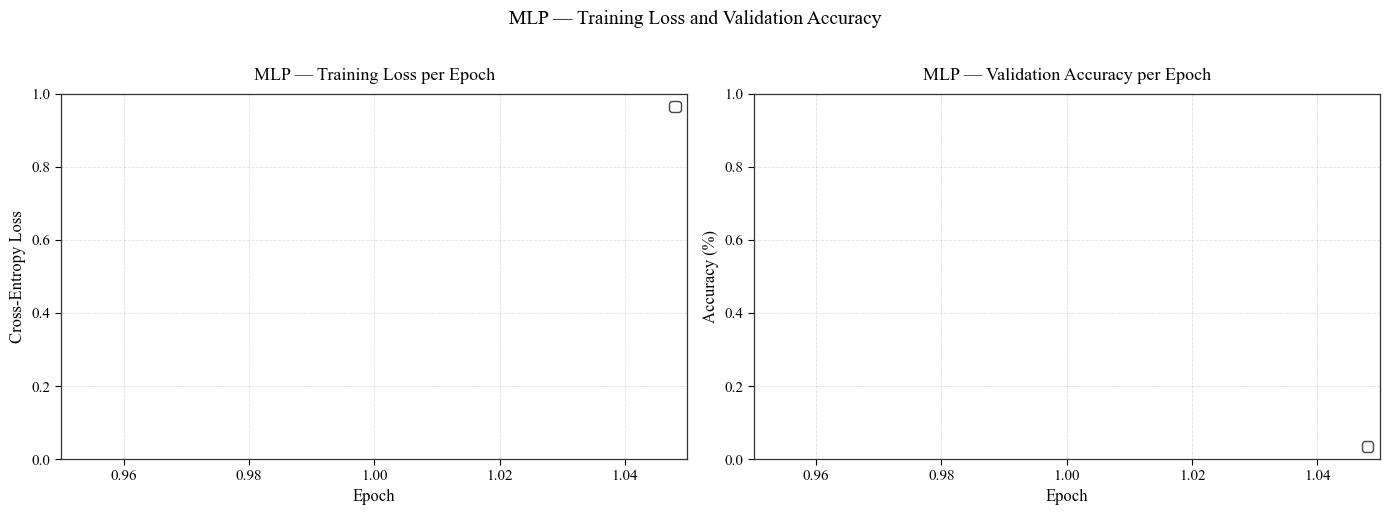

In [6]:
_plot_curves('mlp', _results_log)

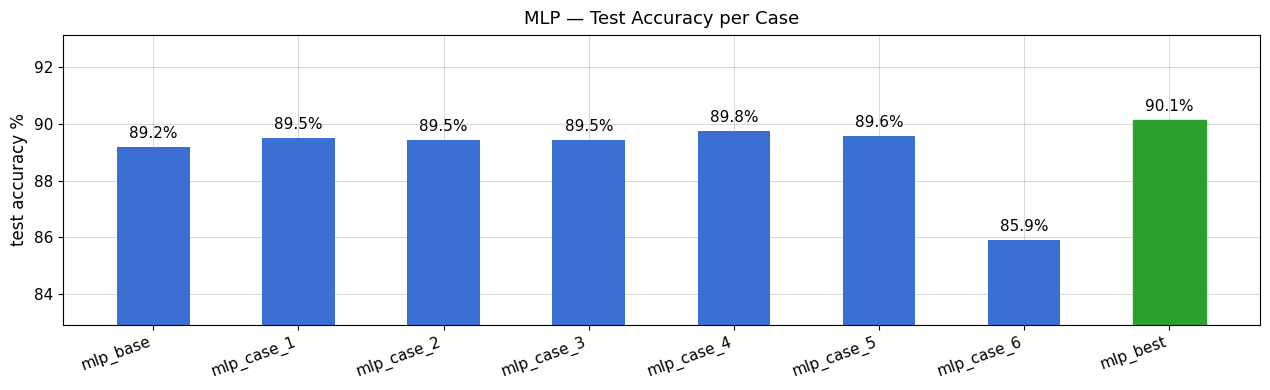

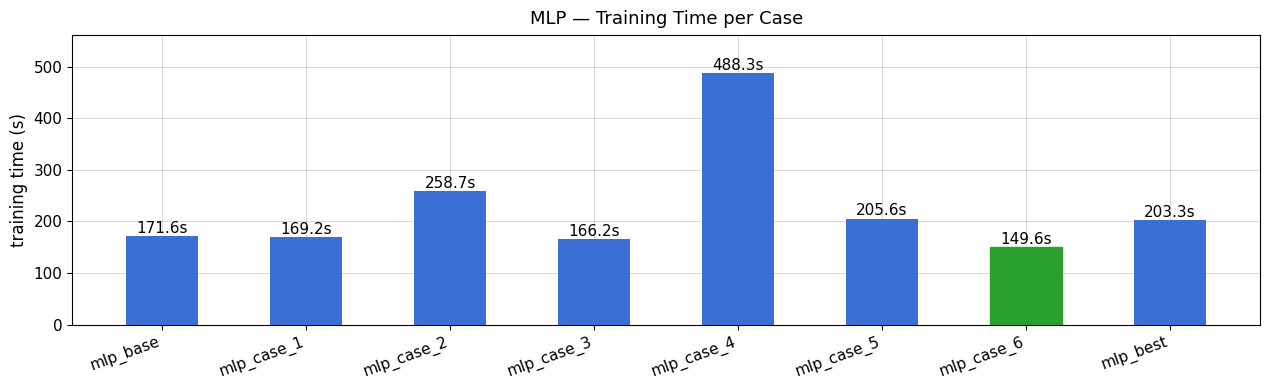

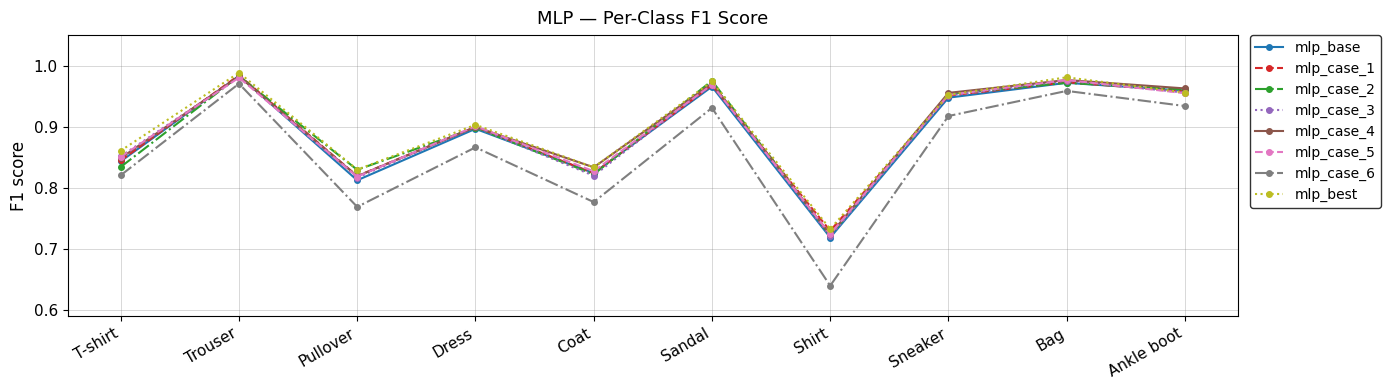

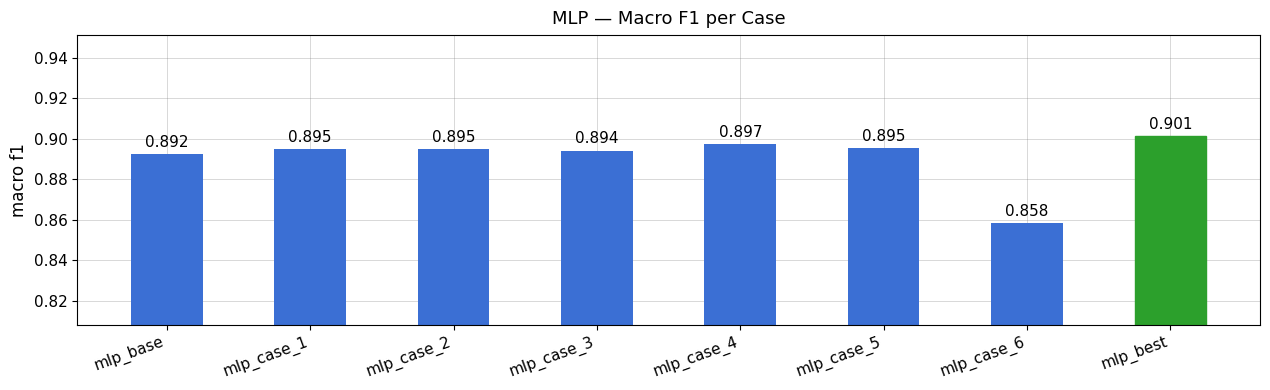

In [6]:
_compare_results('mlp', _results_log)

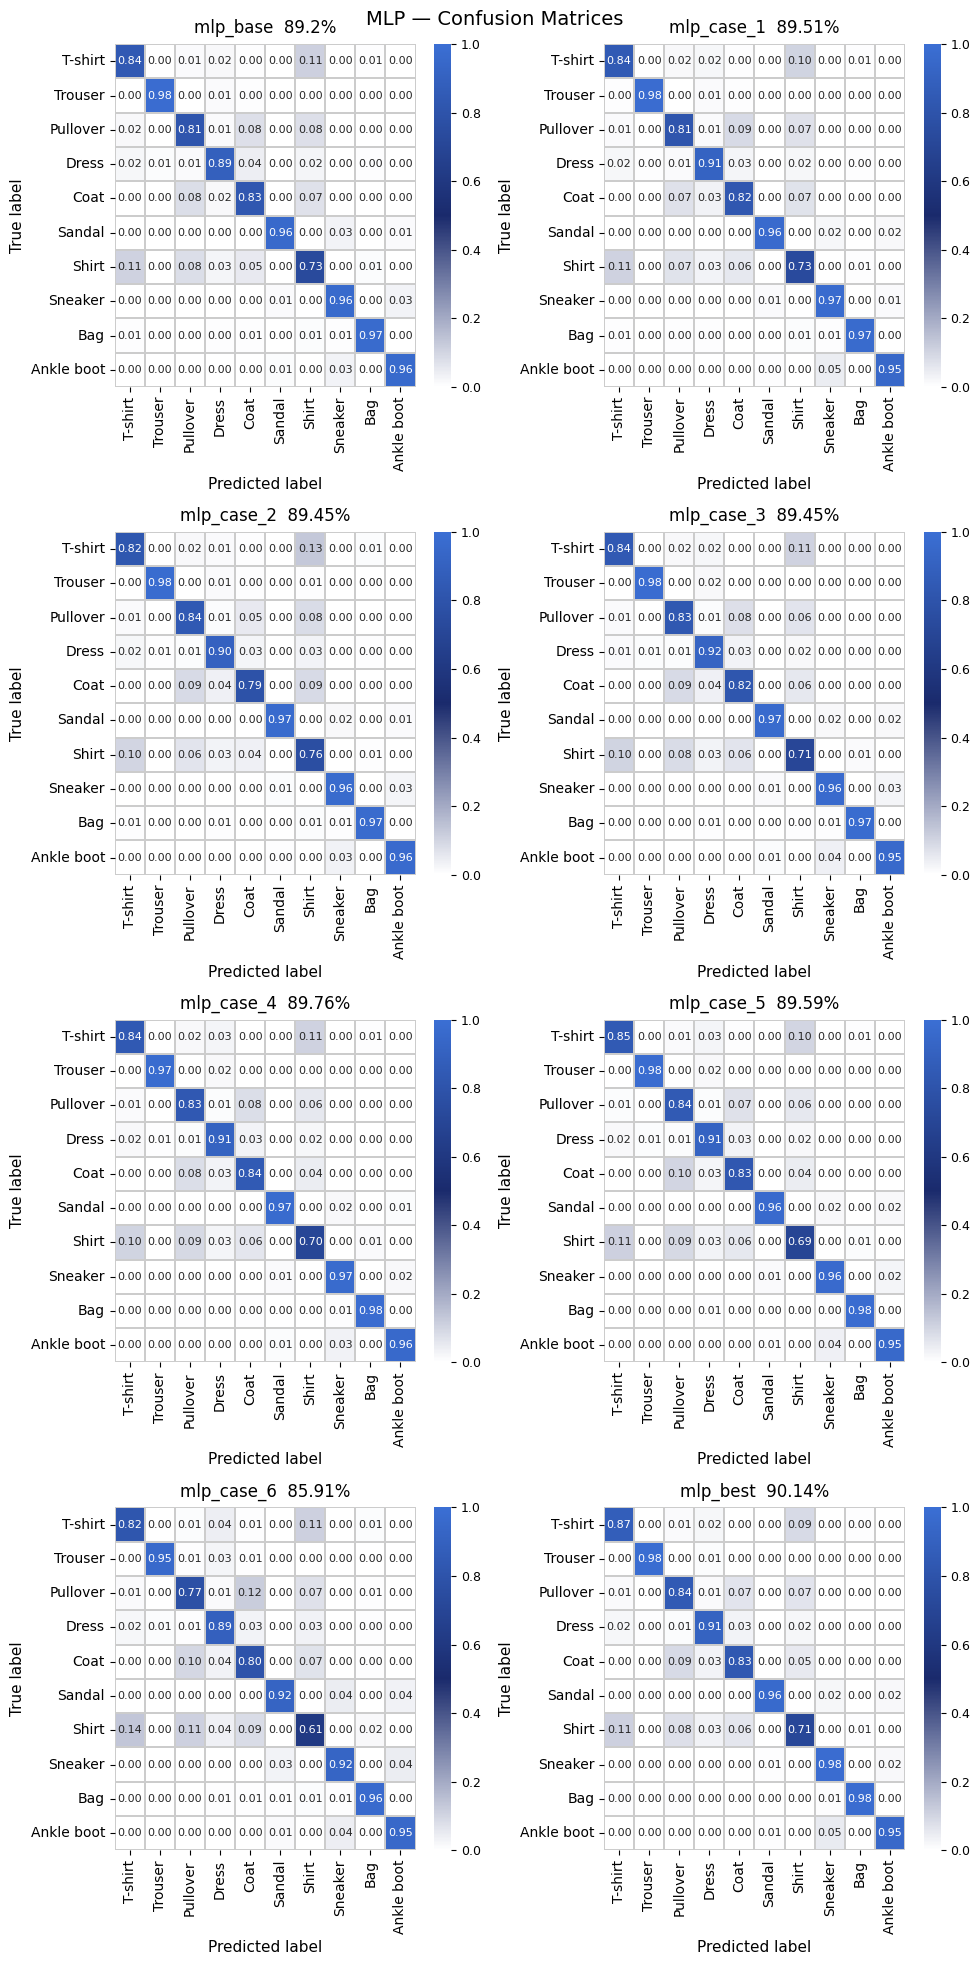

In [7]:
_confusion_matrix('mlp', _results_log)

#### Key Findings — MLP

- **Width** [128]→[256] gives a small gain (+0.31pp); pure depth [256]→[256,128] adds minimal benefit alone.
- **Dropout** (0.3) does not hurt accuracy and marginally improves validation generalisation.
- **Batch norm + dropout together** (case 4) outperform either regulariser alone.
- **GELU > ReLU** slightly on this task — smoother gradient flow helps.
- **SGD severely underperforms** Adam-family: −3.85pp, even with a tuned learning rate.
- **Best MLP** stacks all improvements: [512, 256, 128] + GELU + dropout(0.3) + BN + AdamW → **90.14% test accuracy**.

| Case | Architecture | Test Acc | Macro F1 | Params |
|------|-------------|----------|----------|--------|
| mlp_base | [128] | 89.20% | 0.8923 | 101,770 |
| mlp_case_1 | [256] | 89.51% | 0.8952 | 203,530 |
| mlp_case_2 | [256, 128] | 89.45% | 0.8951 | 235,146 |
| mlp_case_3 | [256, 128] + dropout | 89.45% | 0.8943 | 235,146 |
| mlp_case_4 | [256, 128] + dropout + BN | 89.76% | 0.8973 | 235,914 |
| mlp_case_5 | [256, 128] + GELU | 89.59% | 0.8954 | 235,146 |
| mlp_case_6 | [256, 128] + SGD | 85.91% | 0.8584 | 235,146 |
| **mlp_best** | **[512, 256, 128]** | **90.14%** | **0.9012** | **569,226** |

---
## 4. Cross-Model Comparison

| Model | Best Test Acc | Macro F1 | Training Data | Key Strength |
|-------|---------------|----------|---------------|--------------|
| **MLP** | **90.14%** | **0.9012** | 54,000 samples | Highest accuracy; leverages full dataset |
| SVM | 87.11% | 0.8780 | 3,200 samples | Fast training; strong with small data |
| RVM | TBD | TBD | — | Probabilistic outputs; sparse inference |

**Discussion:**

- MLP leads by ~3pp over the best SVM, but requires the full training set and a GPU for practical training times.
- SVM accuracy is strongly data-limited — with more data it closes the gap significantly.
- RVM provides the sparsest model and the only probabilistic classifier; directly compared to SVM in case 7.
- All three models show the most confusion between visually similar classes: Shirt vs T-shirt/top, Coat vs Pullover — reflected in their confusion matrices.

In [ ]:
df_svm = pd.read_csv('results/svm_experiments.csv')
df_mlp = pd.read_csv('results/mlp_experiments.csv')

---
## 5. Best Case Summary Plots

Two plots comparing only the **best-performing case** from each model:
1. Grouped bar chart — Test Accuracy and Macro F1
2. Side-by-side confusion matrices

In [ ]:
from case_metric_plots import _plot_best_cases
from build_svm import _svm_results_log
from build_rvm import _rvm_results_log
from build_mlp import _results_log

_plot_best_cases(
    svm_results=_svm_results_log,
    rvm_results=_rvm_results_log,
    mlp_results=_results_log,
)